In [1]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.stats
import sys
import os
from collections import namedtuple

# LaTex Formatierung in Plots
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "Computer Modern"
# })

In [2]:
def Tau(T0, T1, Tm, m1, m0, cw):
    return (cw * (m1*((T1-Tm)/(Tm-T0)) - m0))

def SpezifischeKapazität(T1, T2, Tm, m1, mTest, cw, ck):
    """
    T1: Temperatur Wasser
    T2: Temperatur Testobjekt
    Tm: Temperatur Mischung
    m1: Masse Wasser
    mTest: Masse Testobjekt
    cw: Spezifische Kapazität Wasser
    ck: Wärmekapazität Kalorimeter (Tau)
    """
    return ( (1/mTest) * (m1 * cw + ck) * ((Tm -T1)/(T2-Tm)))

c_Wasser = 4.182e3 # J/(kg K)

# Formeln für Quadratischen Fit
class LinRegress:
    """Klasse der Funktionen für eine linearen Regression nach Datenanalyse A."""
    def __init__(self):
        pass

    def Regression(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Macht eine vollständige Regression."""
        LinregressResult = namedtuple("LinregressResult", ["slope", "intercept", "stderr", "intercept_stderr"])
        steigung = self.b_hat(x, y, Ursprungsgerade)
        sig_steigung = self.b_delta(x, y, Ursprungsgerade)

        if Ursprungsgerade:
            achsenabschnitt = 0
            sig_achsenabschnitt = 0
        else:
            achsenabschnitt = self.a_hat(x, y)
            sig_achsenabschnitt = self.a_delta(x, y)

        return LinregressResult(
            steigung, 
            achsenabschnitt, 
            sig_steigung, 
            sig_achsenabschnitt
        )

    def a_hat(self, x:np.array, y:np.array):
        """Berechnet die Bestwerte für den Y-Achsenabschnitt."""
        return (np.sum(x**2)*np.sum(y) - np.sum(x)*np.sum(x*y)) / (len(x) * np.sum(x**2) - (np.sum(x))**2)

    def b_hat(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Bestwerte für die Steigung."""
        if Ursprungsgerade:
            return (np.sum(x*y)) / np.sum(x**2)
        else:
            return (len(x) * np.sum(x*y) - (np.sum(x) * np.sum(y)))/(len(x) * np.sum(x**2) - (np.sum(x))**2) 

    def Streuung(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Streuung der Messwerte um das gefittete Modell. (Wird genutzt da die Standardunsicherheiten der Messgröße y unbekannt sind)"""
        if Ursprungsgerade:
            return np.sqrt((1 / (len(x) - 1)) * np.sum((y - (self.b_hat(x, y) * x))**2))
        else:
            return np.sqrt(((1)/(len(x)-2)) * (np.sum(y - (self.a_hat(x, y) + self.b_hat(x, y) * x)))**2)

    def a_delta(self, x:np.array, y:np.array):
        """Berechnet die Standartunsicherheit von dem Y-Achsenabschnitt â."""
        return self.Streuung(x, y) * np.sqrt( (np.sum(x**2)) / (len(x)*np.sum(x**2) - np.sum(x)**2))

    def b_delta(self, x:np.array, y:np.array, Ursprungsgerade:bool=False):
        """Berechnet die Standartunsicherheit von der Steigung ^b für Ursprungsgeraden und nicht Ursprungsgeraden."""
        return  self.Streuung(x, y, Ursprungsgerade=Ursprungsgerade) * np.sqrt(len(x) / (len(x) * np.sum(x*2) - np.sum(x)*2))

    def unsicherheit_an_Wert(self, x:np.array, y:np.array, x_Position, Ursprungsgerade:bool=False):
        """Berechnet die Standardunsicherheit des Modells an einer belibigen Stelle x. Der dadurch definierte Bereich um die beste ausgleichsgerade ist das 1 sigma Konfidenzband."""
        s = self.Streuung(x, y,Ursprungsgerade=Ursprungsgerade)
        n = len(x)
        db = self.b_delta(x, y, Ursprungsgerade=Ursprungsgerade)
        mean_x = np.mean(x)

        return np.sqrt( (s / np.sqrt(n))**2 + (db * (x_Position - mean_x))**2 )

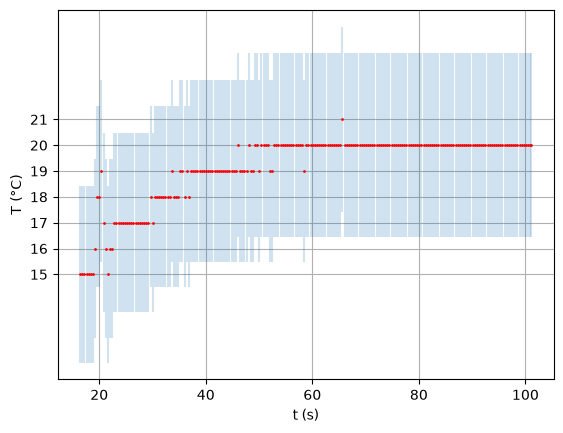

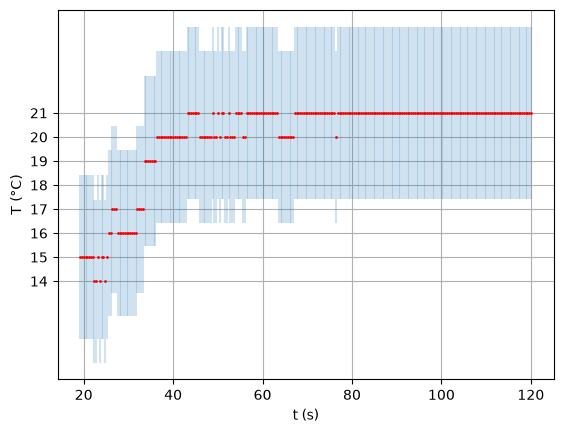

In [3]:
# Plotten 1
files = ["1_1Messung.csv", "2_1Messung.csv", "3_1Messung.csv",
         "1_Aluminium.csv", "2_Aluminium.csv", 
         "1_Messing.csv", "2_Messing.csv"]

files = ["2_Aluminium.csv", "2_Messing.csv"]

for file in files: 
    messdaten = pd.read_csv(file)
    messdaten = messdaten.rename(columns={"video_time_sec": "Zeit (s)", "value": "T (°C)"}) # Rename Cols
    messdaten[r"$\Delta T$ (°C)"] = (messdaten["T (°C)"] * 0.028) + 3 # Fehler berechnen

    # Plotten
    fig, ax = plt.subplots()#dpi=500)
    ax.errorbar(messdaten["Zeit (s)"], messdaten["T (°C)"], yerr=messdaten[r"$\Delta T$ (°C)"], fmt=',', alpha=0.2, capsize=0)
    ax.plot(messdaten["Zeit (s)"], messdaten["T (°C)"], '.', color="red", markersize=2)

    ax.set_ylabel("T (°C)")
    ax.set_xlabel("t (s)")
    ax.set_yticks(np.arange(min(messdaten["T (°C)"]), max(messdaten["T (°C)"]) + 1))
    ax.grid()
    # ax.set_title(str(file))
    plt.show()



T kalt = 14.000000000000028 +- 4.4541979371861043e-14
T Mischung = 34.11587282781661 +- 1.308034965926065e-13
Wärmekapazität c des Aufbaus: 42.41366571342102


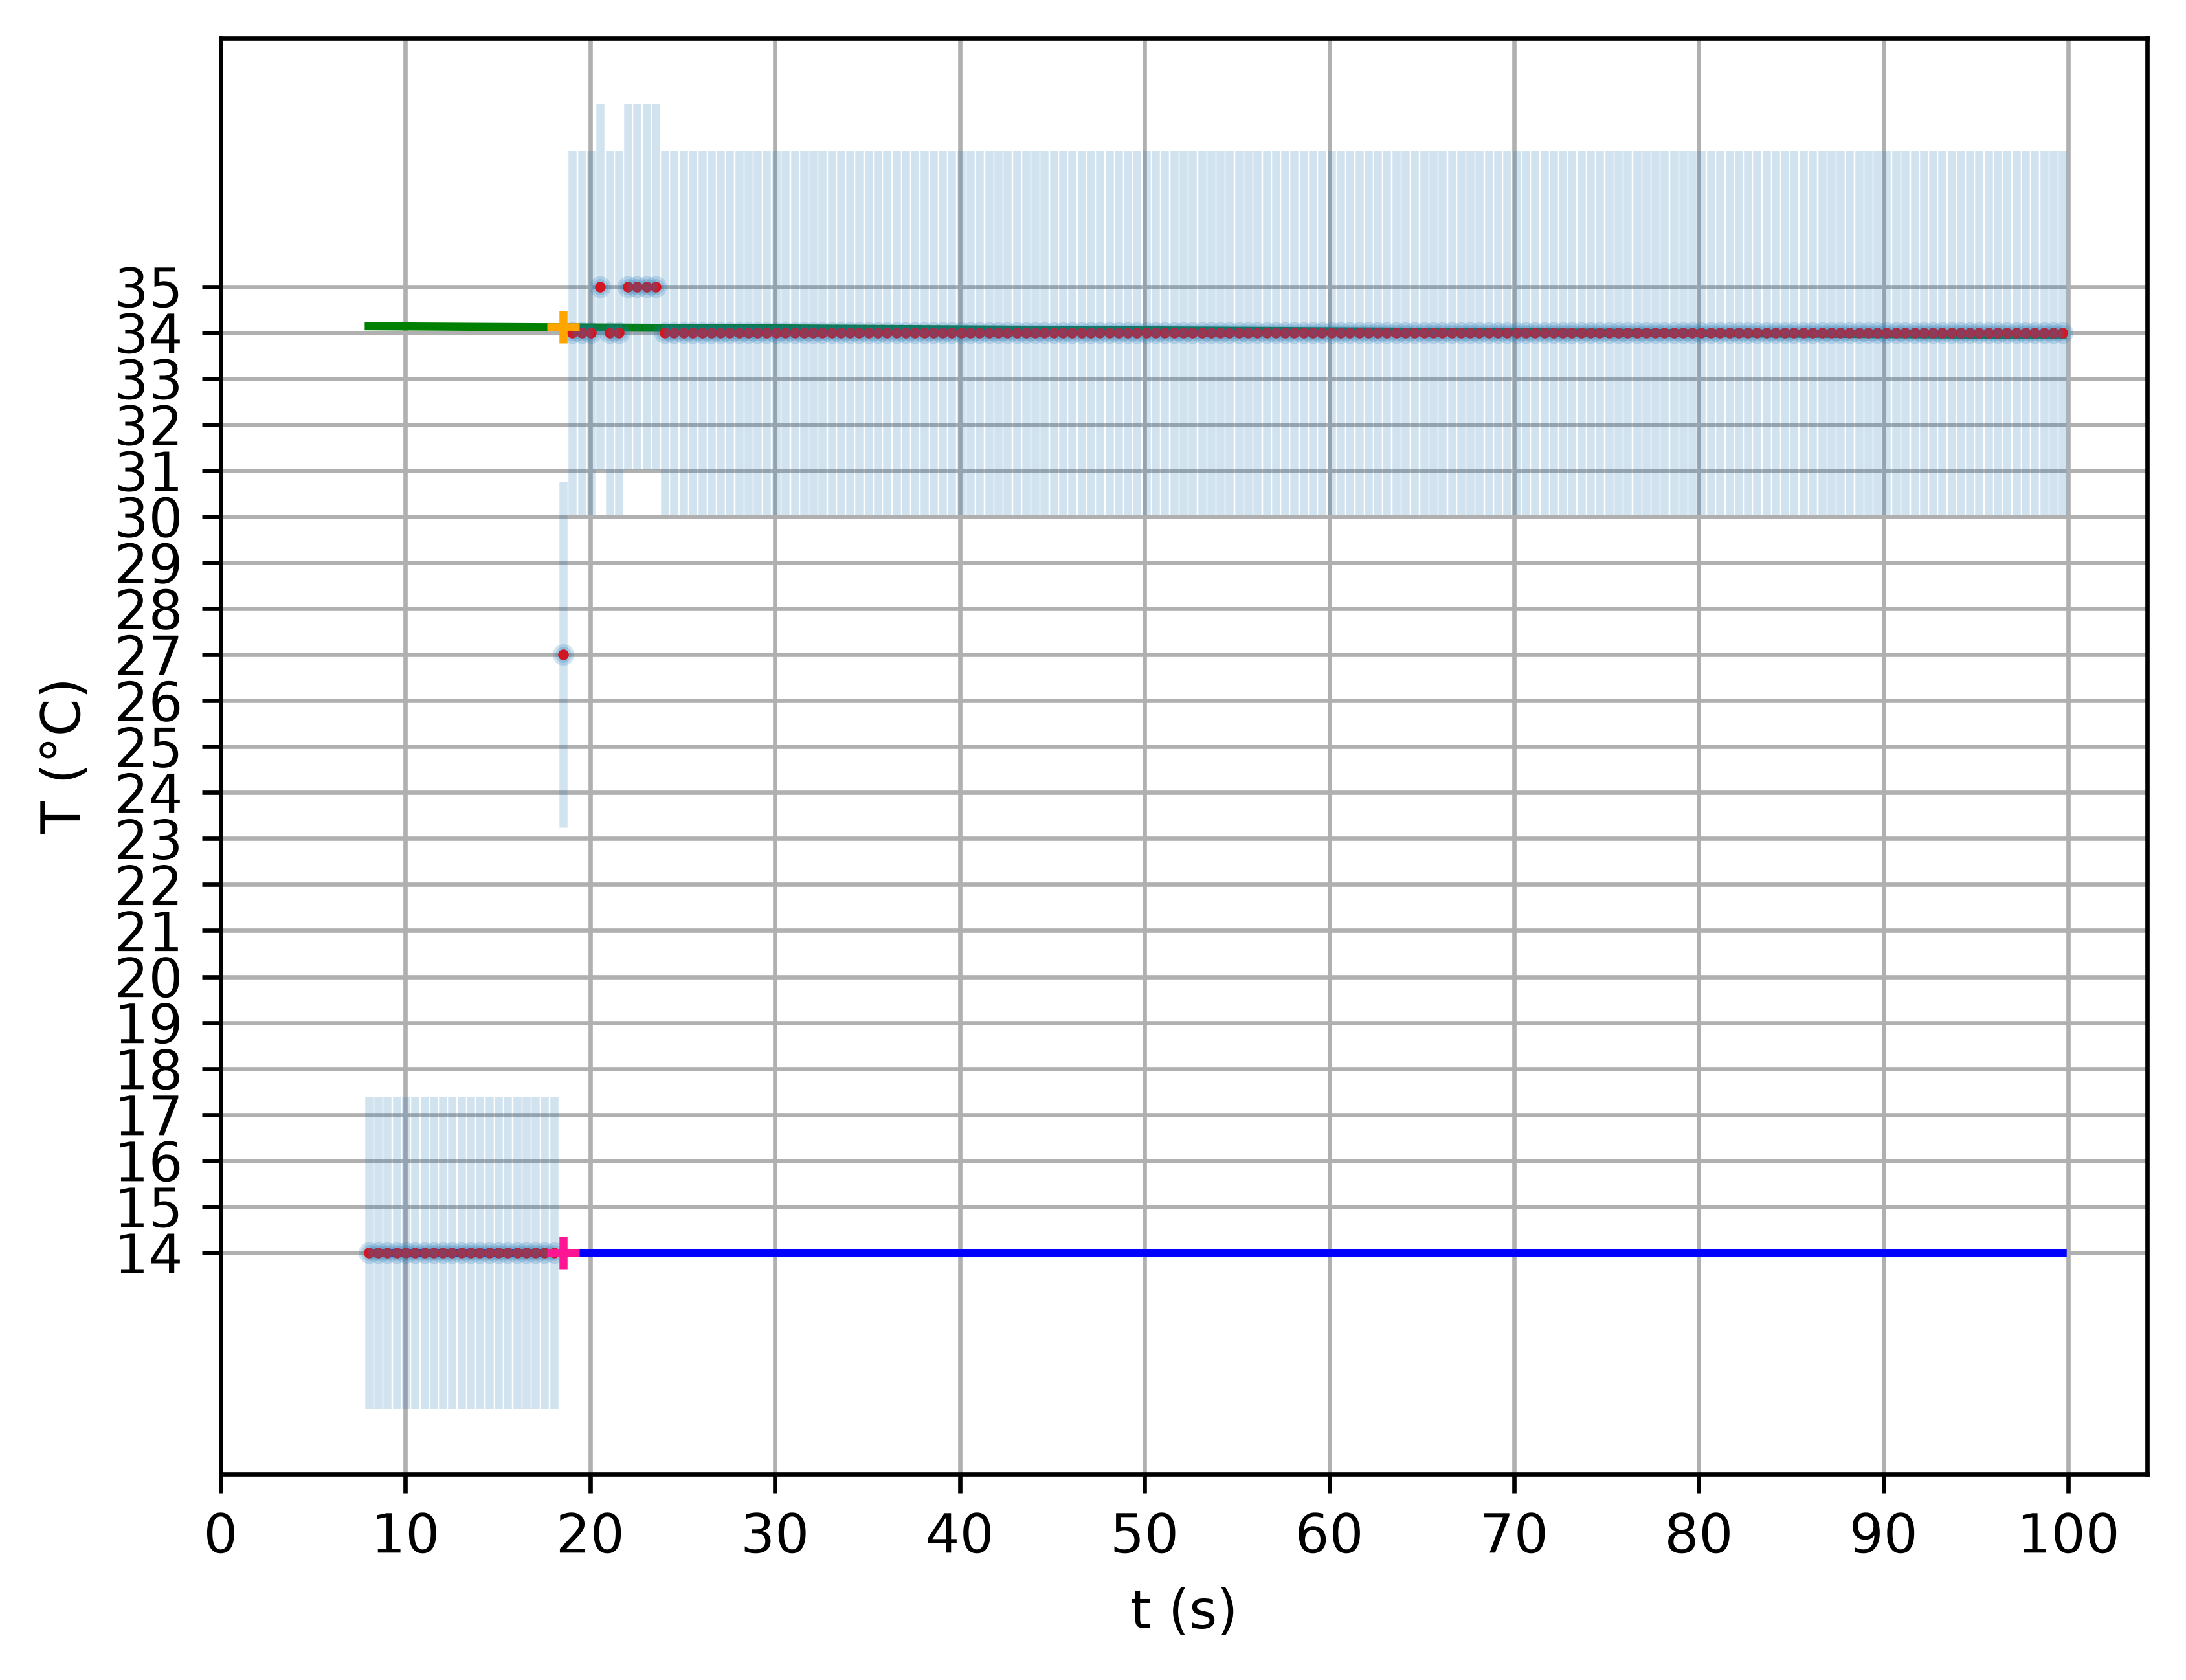

In [4]:
# Auswertung 1
file = "3_1Messung.csv"

messdaten = pd.read_csv(file)
messdaten = messdaten.rename(columns={"video_time_sec": "Zeit (s)", "value": "T (°C)"}) # Rename Cols
messdaten[r"$\Delta T$ (°C)"] = (messdaten["T (°C)"] * 0.028) + 3 # Fehler berechnen

c0_messdaten = messdaten[messdaten["Zeit (s)"] <= 100]
c1_messdaten = messdaten[messdaten["T (°C)"] == 14]
c2_messdaten = c0_messdaten[(c0_messdaten["Zeit (s)"] > 18.7)]

# Datenanalyse A
lr = LinRegress()
c1_linfit = lr.Regression(x=c1_messdaten["Zeit (s)"], y=c1_messdaten["T (°C)"])
c2_linfit = lr.Regression(c2_messdaten["Zeit (s)"], c2_messdaten["T (°C)"])

T_kalt = float(
    c1_linfit.intercept
    + c1_linfit.slope * c0_messdaten["Zeit (s)"][c0_messdaten["T (°C)"] == 27].item()
)

T_mischung = float(
    c2_linfit.intercept
    + c2_linfit.slope * c0_messdaten["Zeit (s)"][c0_messdaten["T (°C)"] == 27].item()
)

print()
print("T kalt =", T_kalt, "+-", lr.unsicherheit_an_Wert(c1_messdaten["Zeit (s)"], c1_messdaten["T (°C)"], c0_messdaten["Zeit (s)"][c0_messdaten["T (°C)"] == 27].item()))
print("T Mischung =", T_mischung, "+-", lr.unsicherheit_an_Wert(c2_messdaten["Zeit (s)"], c2_messdaten["T (°C)"], c0_messdaten["Zeit (s)"][c0_messdaten["T (°C)"] == 27].item()))


T_heiss = 92  # Temperatur des heißen Wassers in °C
m_kalt = 0.151  # Masse des kalten Wassers in kg
m_heiss = 0.056  # Masse des heißen Wassers in kg

C_Aufbau = Tau(
    T0=T_kalt,
    T1=T_heiss,
    Tm=T_mischung,
    m0=m_kalt,
    m1=m_heiss,
    cw=c_Wasser,
)

print("Wärmekapazität c des Aufbaus:", C_Aufbau)
# print("Temperatur kaltes Wasser:", T_kalt)
# print("Temperatur heißes Wasser:", T_heiss)
# print("Mischtemperatur:", T_mischung)
# print("Masse kalt:", m_kalt)
# print("Masse warm:", m_heiss)
# print("cw Wasser", c_Wasser)


# Plotten
plot_messdaten = c0_messdaten
fig, ax = plt.subplots(dpi=600)

# Messwerte und Fehler Plotten
ax.errorbar(plot_messdaten["Zeit (s)"], plot_messdaten["T (°C)"], yerr=plot_messdaten[r"$\Delta T$ (°C)"], fmt='.', alpha=0.2, capsize=0, zorder=4)
ax.plot(plot_messdaten["Zeit (s)"], plot_messdaten["T (°C)"], '.', color="red", markersize=2, zorder=4)

# fits
ax.plot(c0_messdaten["Zeit (s)"], c1_linfit.intercept + c1_linfit.slope * c0_messdaten["Zeit (s)"], color='blue', zorder=2)
ax.plot(c0_messdaten["Zeit (s)"], c2_linfit.intercept + c2_linfit.slope * c0_messdaten["Zeit (s)"], color='green', zorder=2)

# Temperaturen eintragen
x_wert = c0_messdaten["Zeit (s)"][c0_messdaten["T (°C)"] == 27].item()
ax.scatter(x_wert,  c1_linfit.intercept + c1_linfit.slope * x_wert, marker='+', zorder=5, color="deeppink")
ax.scatter(x_wert,  c2_linfit.intercept + c2_linfit.slope * x_wert, marker='+', zorder=5, color="orange")

ax.set_ylabel("T (°C)")
ax.set_xlabel("t (s)")
ax.set_yticks(np.arange(min(plot_messdaten["T (°C)"]), max(plot_messdaten["T (°C)"]) + 1))
ax.set_xticks(np.arange(0, 101, 10))
ax.grid(zorder=0)
plt.show()

In [5]:
# Herrumspielen um Werte zu vergleichen

T_heiss = 92
m_kalt = 0.151
m_heiss = 0.056
T_kalt = 14
T_mischung = 34

C_Aufbau_Test = Tau(
    T0=T_kalt,
    T1=T_heiss,
    Tm=T_mischung,
    m0=m_kalt,
    m1=m_heiss,
    cw=c_Wasser,
)


print("Temperatur kaltes Wasser:", T_kalt)
print("Temperatur heißes Wasser:", T_heiss)
print("Mischtemperatur:", T_mischung)
print("Masse kalt:", m_kalt)
print("Masse warm:", m_heiss)
print("cw Wasser", c_Wasser)
print("--------------")
print("Wärmekapazität des Aufbaus:", round(C_Aufbau_Test, 2))

Temperatur kaltes Wasser: 14
Temperatur heißes Wasser: 92
Mischtemperatur: 34
Masse kalt: 0.151
Masse warm: 0.056
cw Wasser 4182.0
--------------
Wärmekapazität des Aufbaus: 47.67


In [6]:
# Teil 2
# Messing spezifische Wärmekapazität
m_Test = 0.213 #kg
m_wasser = 0.205 #kg
T_körper_heiss = 94 #°
T_wasser_kalt = 15 #°
T_mischung = 21 #° 
print("Messing c:", SpezifischeKapazität(T_wasser_kalt, T_körper_heiss, T_mischung, m_wasser, m_Test, c_Wasser, C_Aufbau))


# Alu spezifische Wärmekapazität
m_Test = 0.071 #kg
T_körper_heiss = 94 #°
T_wasser_kalt = 15 #°
T_mischung = 20 #°
m_wasser = 0.189 #kg
print("Aluminium c:", SpezifischeKapazität(T_wasser_kalt, T_körper_heiss, T_mischung, m_wasser, m_Test, c_Wasser, C_Aufbau))

Messing c: 347.18258372117344
Aluminium c: 792.5501196359165


In [7]:
# Fehlerfortpflanzung für Kalorimeteraufbau, Messing und Aluminium
# Annahmen: ΔT = 0,028·|T| + 3 °C als Standardunsicherheit;
# Massenauflösung 1 g (Rechteckverteilung), c_Wasser exakt, Größen unabhängig.
import numpy as np
import pandas as pd
import sympy as sp
# from Tools import gauss_error_values
from IPython.display import display, Math

sigma_m = 1e-3 / np.sqrt(12)
sigma_T = lambda T: 0.028 * abs(float(T)) + 3.0

def fit_prediction(x, y, x0):
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < 3 or len(x) != len(y):
        raise ValueError("Der Temperaturfit benötigt mindestens drei Messpunkte.")
    a, b = np.polyfit(x, y, 1)
    sxx = np.sum((x - np.mean(x)) ** 2)
    if sxx == 0:
        raise ValueError("Die Zeitwerte des Temperaturfits müssen variieren.")
    residuals = y - (a * x + b)
    s2 = np.sum(residuals ** 2) / (len(x) - 2)
    value = a * x0 + b
    error = np.sqrt(s2 * (1 / len(x) + (x0 - np.mean(x)) ** 2 / sxx))
    return float(value), float(error)

# Testzelle überschreibt T_kalt/T_mischung; deshalb die Fitwerte neu bestimmen.
data = pd.read_csv("3_1Messung.csv").rename(
    columns={"video_time_sec": "t", "value": "T"}
)
data = data[data["t"] <= 100]
times = data.loc[data["T"] == 27, "t"].to_numpy(float)
if len(times) != 1:
    raise ValueError("Erwartet wird genau ein Messpunkt bei 27 °C.")
t0 = float(times[0])
cold = data[data["T"] == 14]
mixed = data[data["t"] > 18.7]
T_kalt_wert, dT_kalt_fit = fit_prediction(cold["t"], cold["T"], t0)
T_misch_wert, dT_misch_fit = fit_prediction(mixed["t"], mixed["T"], t0)
dT_kalt = np.hypot(dT_kalt_fit, sigma_T(T_kalt_wert))
dT_misch = np.hypot(dT_misch_fit, sigma_T(T_misch_wert))
relative_denominator_error = np.hypot(dT_kalt, dT_misch) / abs(T_misch_wert - T_kalt_wert)
if relative_denominator_error > 0.2:
    print("Warning: uncertainty of T_mischung - T_kalt exceeds 20%; first-order Gaussian propagation may be inaccurate.")

# Wärmekapazität des Kalorimeteraufbaus
T0, T1, Tm, m1, m0, cw = sp.symbols("T0 T1 Tm m1 m0 cw")
f_C = cw * (m1 * (T1 - Tm) / (Tm - T0) - m0)
C_Aufbau_Fehler = gauss_error_values(
    f_C, [T0, T1, Tm, m1, m0, cw],
    [T_kalt_wert, 92.0, T_misch_wert, 0.056, 0.151, c_Wasser],
    [dT_kalt, sigma_T(92), dT_misch, sigma_m, sigma_m, 0],
    eqLabel="gauss_kalorimeter", variable_name="C_Aufbau",
    unit=" J/K", returnLaTex=True,
)
display(Math(C_Aufbau_Fehler[2]))
display(Math(C_Aufbau_Fehler[3]))

# Die Unsicherheit von C_Aufbau wird in beide Materialwerte übernommen.
Tw, Th, Tmix, mw, mp, cw, ck = sp.symbols("T_wasser T_koerper T_mischung m_wasser m_probe cw ck")
f_c = ((mw * cw + ck) / mp) * ((Tmix - Tw) / (Th - Tmix))
def material_fehler(name, mwert, mprobe, Tmisch):
    return gauss_error_values(
        f_c, [Tw, Th, Tmix, mw, mp, cw, ck],
        [15, 94, Tmisch, mwert, mprobe, c_Wasser, C_Aufbau_Fehler[0]],
        [sigma_T(15), sigma_T(94), sigma_T(Tmisch), sigma_m, sigma_m,
         0, C_Aufbau_Fehler[1]],
        eqLabel=f"gauss_{name.lower()}", variable_name=f"c_{name}",
        unit=" J/(kg K)", returnLaTex=True,
    )

c_Messing_Fehler = material_fehler("Messing", 0.205, 0.213, 21)
display(Math(c_Messing_Fehler[2]))
display(Math(c_Messing_Fehler[3]))
c_Aluminium_Fehler = material_fehler("Aluminium", 0.189, 0.071, 20)
display(Math(c_Aluminium_Fehler[2]))
display(Math(c_Aluminium_Fehler[3]))

NameError: name 'gauss_error_values' is not defined